In [4]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import TypedDict
from langchain_ollama import ChatOllama

In [5]:
llm = ChatOllama(model="llama3.2:3b")
llm

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, model='llama3.2:3b')

In [8]:
class Employee(TypedDict):
    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int
    bonus_amount: int
    project_status: str
    summary: str


In [9]:
def calculate_yearly_salary(state: Employee):
    yearly_salary = state["monthly_salary"] * 12
    return {"yearly_salary": yearly_salary}

def calculate_bonus(state: Employee):
    bonus_amount = state["completed_projects"] * 1000
    return {"bonus_amount": bonus_amount}

def project_status(state: Employee):
    if state["completed_projects"] > 5:
        status = "Excellent"
    elif state["completed_projects"] > 3:
        status = "Good"
    else:
        status = "Needs Improvement"
    return {"project_status": status}

def summary(state: Employee):
    summary_text = f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']}, a bonus amount of {state['bonus_amount']}, and their project status is {state['project_status']}."
    return {"summary": summary_text}

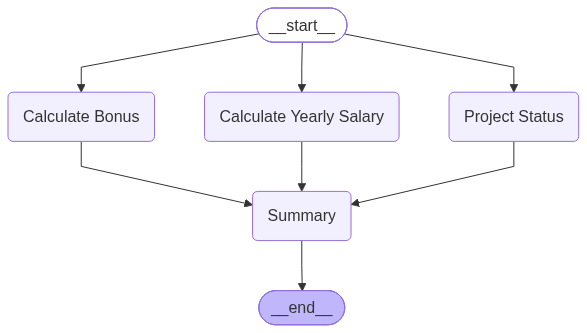

In [10]:
graph = StateGraph(Employee)

graph.add_node("Calculate Yearly Salary", calculate_yearly_salary)
graph.add_node("Calculate Bonus", calculate_bonus)
graph.add_node("Project Status", project_status)
graph.add_node("Summary", summary)

graph.add_edge(START, "Calculate Yearly Salary")
graph.add_edge(START, "Calculate Bonus")
graph.add_edge(START, "Project Status")

graph.add_edge("Calculate Yearly Salary", "Summary")
graph.add_edge("Calculate Bonus", "Summary")
graph.add_edge("Project Status", "Summary")

graph.add_edge("Summary", END)

workflow = graph.compile()
workflow

In [14]:
initial_state = {
    "employee_name": "John Doe",
    "monthly_salary": 5000,
    "working_days": 22,
    "completed_projects": 4
}

final_state = workflow.invoke(initial_state)
final_state  # Output: "Employee John Doe has a yearly salary of 60000, a bonus amount of 6000, and their project status is Excellent."

{'employee_name': 'John Doe',
 'monthly_salary': 5000,
 'working_days': 22,
 'completed_projects': 4,
 'yearly_salary': 60000,
 'bonus_amount': 4000,
 'project_status': 'Good',
 'summary': 'Employee John Doe has a yearly salary of 60000, a bonus amount of 4000, and their project status is Good.'}